In [1]:
import random
import torch
import requests
import numpy as np
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import v2
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
import wandb
import cv2
import os
import hashlib
import tarfile
from PIL import Image
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/CompVision/lfw_dataset.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Dole_0003.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Hurley_0001.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Hurley_0002.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Hurley_0003.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Hurley_0004.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Hurley_0005.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Shue_0001.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Shue_0002.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Elizabeth_Taylor_0001.ppm  
  inflating: /content/lfw_dataset/parts_lfw_funneled_gt_images/._Eli_Stutsman_0001.ppm  
  inflating: /content/lfw_dat

In [ ]:
class LFWDataset(torch.utils.data.Dataset):

    _DATA = (
        # images
        ("http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz", None),
        # segmentation masks as ppm
        ("https://vis-www.cs.umass.edu/lfw/part_labels/parts_lfw_funneled_gt_images.tgz",
         "3e7e26e801c3081d651c8c2ef3c45cfc"),
    )

    def __init__(self, base_folder, transforms=None, download=True, split_name: str = "train"):
        super().__init__()
        self.transforms = transforms
        self.base_folder = base_folder

        if download:
            self.download_resources(base_folder)

        self.images_dir = os.path.join(base_folder, "lfw_funneled")
        self.masks_dir = os.path.join(base_folder, "parts_lfw_funneled_gt_images")

        if not os.path.isdir(self.images_dir):
            raise RuntimeError(f"Images directory not found: {self.images_dir}. Set download=True.")
        if not os.path.isdir(self.masks_dir):
            raise RuntimeError(f"Masks directory not found: {self.masks_dir}. Set download=True.")

        # Build lookup: filename stem (lowercase) -> mask path
        mask_lookup = {}
        for root, _, files in os.walk(self.masks_dir):
            for fname in files:
                if fname.startswith("._"):
                    continue
                if not fname.endswith(".ppm"):
                    continue

                key = fname.replace(".ppm", "").lower().strip()
                mask_lookup[key] = os.path.join(root, fname)

        # Not all images have masks — only keep matched pairs
        self.samples = []
        for person in os.listdir(self.images_dir):
            person_dir = os.path.join(self.images_dir, person)
            if not os.path.isdir(person_dir):
                continue
            for img_name in os.listdir(person_dir):
                if img_name.startswith("._") or not img_name.endswith(".jpg"):
                    continue
                key = img_name.replace(".jpg", "").lower().strip()
                if key in mask_lookup:
                    self.samples.append((os.path.join(person_dir, img_name), mask_lookup[key]))

        if len(self.samples) == 0:
            raise RuntimeError("No matching image-mask pairs found.")

        # Deterministic, reproducible split via MD5 hash of path
        self.samples.sort(key=lambda x: hashlib.md5(x[0].encode()).hexdigest())
        split_idx = int(0.8 * len(self.samples))
        if split_name == "train":
            self.samples = self.samples[:split_idx]
        else:
            self.samples = self.samples[split_idx:]

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)
        else:
            image = TF.to_tensor(image)
            mask = np.array(mask)
            if mask.ndim == 3:
                mask = np.argmax(mask, axis=2)
            mask = torch.from_numpy(mask).long()

        return image, mask

    def __len__(self):
        return len(self.samples)

    # ---- download utilities ----

    def download_resources(self, base_folder):
        if not os.path.exists(base_folder):
            os.makedirs(base_folder)
        self._download_and_extract_archive( url=LFWDataset._DATA[1][0], base_folder=base_folder, md5=LFWDataset._DATA[1][1])
        self._download_and_extract_archive(url=LFWDataset._DATA[0][0], base_folder=base_folder, md5=None)

    def _download_and_extract_archive(self, url, base_folder, md5) -> None:
        base_folder = os.path.expanduser(base_folder)
        filename = os.path.basename(url)
        self._download_url(url, base_folder, md5)
        archive = os.path.join(base_folder, filename)
        print(f"Extracting {archive} to {base_folder}")
        self._extract_tar_archive(archive, base_folder, True)

    def _retrieve(self, url, save_location, chunk_size: int = 1024 * 32) -> None:
        try:
            response = requests.get(url, stream=True)
            total_size = int(response.headers.get("content-length", 0))
            with open(save_location, "wb") as file, tqdm(
                desc=os.path.basename(save_location),
                total=total_size,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
            ) as bar:
                for data in response.iter_content(chunk_size=chunk_size):
                    file.write(data)
                    bar.update(len(data))
            print(f"Download successful. File saved to: {save_location}")
        except Exception as e:
            print(f"An error occurred: {str(e)}")

    def _download_url(self, url: str, base_folder: str, md5: str = None) -> None:
        base_folder = os.path.expanduser(base_folder)
        filename = os.path.basename(url)
        file_path = os.path.join(base_folder, filename)
        os.makedirs(base_folder, exist_ok=True)

        if self._check_file(file_path, md5):
            print(f"File {file_path} already exists. Using that version")
            return

        print(f"Downloading {url} to {file_path}")
        self._retrieve(url, file_path)

        if not self._check_file(file_path, md5):
            raise RuntimeError("File not found or corrupted.")

    def _extract_tar_archive(self, from_path: str, to_path: str = None, remove_finished: bool = False) -> str:
        if to_path is None:
            to_path = os.path.dirname(from_path)
        with tarfile.open(from_path, "r") as tar:
            tar.extractall(to_path)
        if remove_finished:
            os.remove(from_path)
        return to_path

    def _compute_md5(self, filepath: str, chunk_size: int = 1024 * 1024) -> str:
        with open(filepath, "rb") as f:
            md5 = hashlib.md5()
            while chunk := f.read(chunk_size):
                md5.update(chunk)
            return md5.hexdigest()

    def _check_file(self, filepath: str, md5: str) -> bool:
        if not os.path.isfile(filepath):
            return False
        if md5 is None:
            return True
        return self._compute_md5(filepath) == md5

Data Loader

0 torch.Size([4, 3, 250, 250]) torch.Size([4, 250, 250])


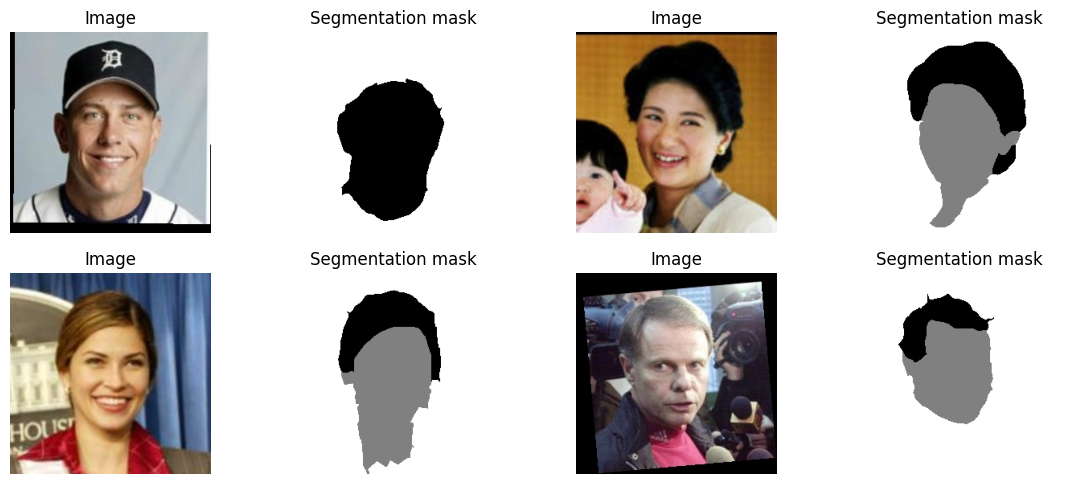

In [5]:
batch_size = 4
ds = LFWDataset(base_folder="lfw_dataset", transforms=None, download=False)
dataloader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

for i_batch, sample_batched in enumerate(dataloader):
    image, segmentation_mask = sample_batched
    print(i_batch, image.size(), segmentation_mask.size())

    rows, cols = batch_size, 4
    figure = plt.figure(figsize=(14, 12))
    for i in range(0, batch_size):
        figure.add_subplot(rows, cols, 2 * i + 1)
        plt.title("Image")
        plt.axis("off")
        plt.imshow(image[i].permute(1, 2, 0).numpy())

        figure.add_subplot(rows, cols, 2 * i + 2)
        plt.title("Segmentation mask")
        plt.axis("off")
        plt.imshow(segmentation_mask[i].numpy(), cmap="gray")

    plt.show()

    if i_batch == 0:
        break

Augumenting images

In [6]:
class PairedTransform:
    def __call__(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        angle = random.uniform(-15, 15)
        image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        i, j, h, w = transforms.RandomCrop.get_params(image, output_size=(200, 200))
        image = TF.crop(image, i, j, h, w)
        mask = TF.crop(mask, i, j, h, w)

        image = TF.to_tensor(image)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = np.argmax(mask, axis=2)
        mask = torch.from_numpy(mask).long()

        return image, mask

paired_transform = PairedTransform()
ds = LFWDataset(base_folder="lfw_dataset", transforms=paired_transform, download=False)

0 torch.Size([4, 3, 200, 200]) torch.Size([4, 200, 200])


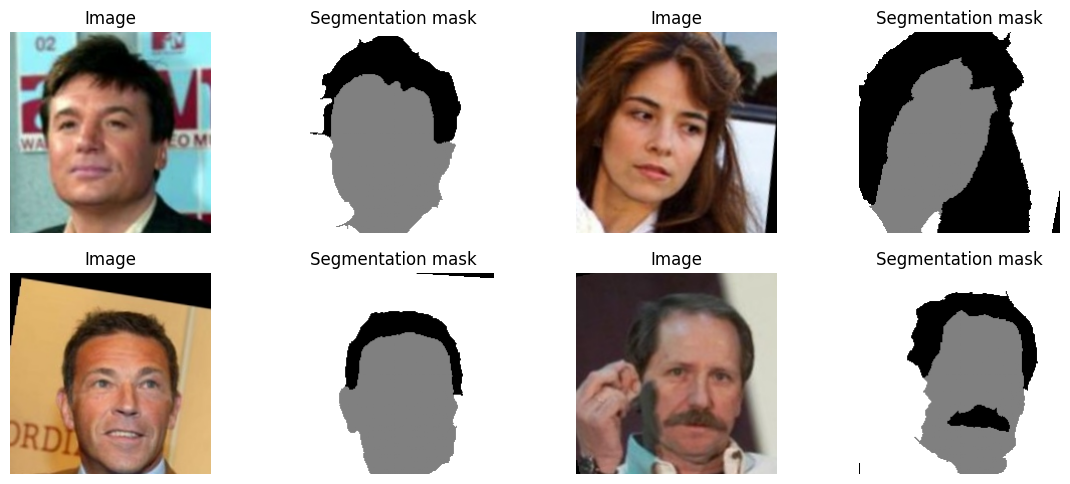

In [7]:
batch_size = 4
dataloader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

for i_batch, sample_batched in enumerate(dataloader):
    image, segmentation_mask = sample_batched
    print(i_batch, image.size(), segmentation_mask.size())

    rows, cols = batch_size, 4
    figure = plt.figure(figsize=(14, 12))
    for i in range(0, batch_size):
        figure.add_subplot(rows, cols, 2 * i + 1)
        plt.title("Image")
        plt.axis("off")
        plt.imshow(image[i].permute(1, 2, 0).numpy())

        figure.add_subplot(rows, cols, 2 * i + 2)
        plt.title("Segmentation mask")
        plt.axis("off")
        plt.imshow(segmentation_mask[i].numpy(), cmap="gray")

    plt.show()

    if i_batch == 0:
        break

In [8]:
class V2PairedTransform:
    def __init__(self):
        self.augment = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(15),
            v2.RandomCrop((200, 200)),
        ])

    def __call__(self, image, mask):
        image, mask = self.augment(image, mask)
        image = TF.to_tensor(image)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = np.argmax(mask, axis=2)
        mask = torch.from_numpy(mask).long()
        return image, mask

ds = LFWDataset(base_folder="lfw_dataset", transforms=V2PairedTransform(), download=False)

0 torch.Size([4, 3, 200, 200]) torch.Size([4, 200, 200])


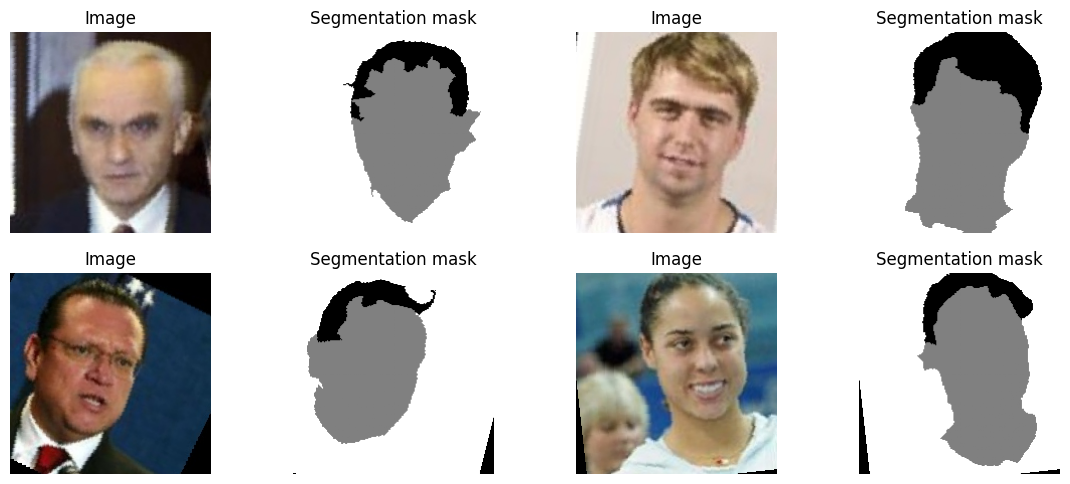

In [9]:
batch_size = 4
dataloader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

for i_batch, sample_batched in enumerate(dataloader):
    image, segmentation_mask = sample_batched
    print(i_batch, image.size(), segmentation_mask.size())

    rows, cols = batch_size, 4
    figure = plt.figure(figsize=(14, 12))
    for i in range(0, batch_size):
        figure.add_subplot(rows, cols, 2 * i + 1)
        plt.title("Image")
        plt.axis("off")
        plt.imshow(image[i].permute(1, 2, 0).numpy())

        figure.add_subplot(rows, cols, 2 * i + 2)
        plt.title("Segmentation mask")
        plt.axis("off")
        plt.imshow(segmentation_mask[i].numpy(), cmap="gray")

    plt.show()

    if i_batch == 0:
        break

In [10]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

In [11]:
class Encoder(nn.Module):

    def __init__(self, channels=[3, 64, 128, 256]):
        super().__init__()

        self.blocks = nn.ModuleList()

        for i in range(len(channels) - 1):
            self.blocks.append(ConvBlock(channels[i], channels[i + 1]))

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        features = []

        for block in self.blocks:
            x = block(x)
            features.append(x)
            x = self.pool(x)

        return features

In [12]:
class UpSampleBlock(nn.Module):

    def __init__(self, in_channels, out_channels, mode="transpose"):
        super().__init__()
        self.mode = mode

        if mode == "transpose":
            self.up = nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            )
        elif mode in ("bilinear", "nearest"):
            self.up = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            )
        else:
            raise ValueError(f"Unknown upsample mode: {mode}")

    def forward(self, x):
        if self.mode in ("bilinear", "nearest"):
            x = F.interpolate(x, scale_factor=2, mode=self.mode, align_corners=False if self.mode == "bilinear" else None)
        return self.up(x)

In [13]:
class Decoder(nn.Module):

    def __init__(self, channels=[256, 128, 64], upsample_mode="transpose"):
        super().__init__()

        self.up_blocks = nn.ModuleList()
        self.conv_blocks = nn.ModuleList()

        for i in range(len(channels) - 1):

            self.up_blocks.append(UpSampleBlock(channels[i], channels[i + 1], mode=upsample_mode))

            self.conv_blocks.append(
                ConvBlock(
                    channels[i],
                    channels[i + 1]
                )
            )

    def forward(self, x, encoder_features):

        for i in range(len(self.up_blocks)):

            x = self.up_blocks[i](x)

            enc_feat = encoder_features[i]

            crop = T.CenterCrop([x.shape[2], x.shape[3]])
            enc_feat = crop(enc_feat)

            x = torch.cat([x, enc_feat], dim=1)

            x = self.conv_blocks[i](x)

        return x

In [14]:
class UNet(nn.Module):

    def __init__(self, num_classes=3, upsample_mode="transpose"):
        super().__init__()

        self.encoder = Encoder()
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(256, 512)
        self.decoder = Decoder(channels=[512, 256, 128, 64], upsample_mode=upsample_mode)

        self.final_conv = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        input_size = x.shape[2:]

        enc_features = self.encoder(x)

        bottleneck_input = self.pool(enc_features[-1])

        x = self.bottleneck(bottleneck_input)

        skip_connections = enc_features[::-1]

        x = self.decoder(x, skip_connections)

        x = self.final_conv(x)

        x = F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return x

In [15]:
model = UNet(num_classes=3)

x = torch.randn(2, 3, 200, 200)

y = model(x)

print(y.shape)

torch.Size([2, 3, 200, 200])


Loss functions

In [16]:
# Cross Entropy Loss

ce_criterion = nn.CrossEntropyLoss()

In [17]:
# Dice Loss

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        # predictions:
        # [B, C, H, W]

        # targets:
        # [B, H, W]

        num_classes = predictions.shape[1]

        predictions = F.softmax(predictions, dim=1) # transform into probabilities
        targets_one_hot = F.one_hot(targets, num_classes=num_classes)

        # [B, H, W, C] -> [B, c, H, W]
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2)
        targets_one_hot = targets_one_hot.float()

        # flatten
        predictions = predictions.reshape(predictions.shape[0], num_classes, -1)
        targets_one_hot = targets_one_hot.reshape(targets_one_hot.shape[0], num_classes, -1)

        intersection = (predictions * targets_one_hot).sum(dim=2)
        union = predictions.sum(dim=2) + targets_one_hot.sum(dim=2)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice.mean()

        return dice_loss

dice_criterion = DiceLoss()

In [18]:
# Combined Loss

class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.dice_weight = dice_weight

    def forward(self, predictions, targets):
        ce_loss = self.ce(predictions, targets)
        dice_loss = self.dice(predictions, targets)

        total_loss = ce_loss + self.dice_weight * dice_loss
        return total_loss

combined_criterion = CombinedLoss()

In [19]:
# Focal Loss

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, predictions, targets):
        ce_loss = F.cross_entropy(predictions, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

focal_criterion = FocalLoss()

In [20]:
class ValTransform:
    def __call__(self, image, mask):
        image = TF.center_crop(image, (200, 200))
        mask = TF.center_crop(mask, (200, 200))
        image = TF.to_tensor(image)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = np.argmax(mask, axis=2)
        mask = torch.from_numpy(mask).long()
        return image, mask

train_ds = LFWDataset(base_folder="lfw_dataset", transforms=V2PairedTransform(), download=False, split_name="train")
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=4, shuffle=True)

val_ds = LFWDataset(base_folder="lfw_dataset", transforms=ValTransform(), download=False, split_name="val")
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=4, shuffle=False)

In [21]:
def pixel_accuracy(predictions, masks):

    predictions = torch.argmax(predictions, dim=1)
    correct = (predictions == masks).float()
    accuracy = correct.mean()

    return accuracy

In [22]:
def mean_iou(predictions, masks, num_classes=3, smooth=1e-6):
    predictions = torch.argmax(predictions, dim=1)

    pred_one_hot = F.one_hot(predictions, num_classes).permute(0, 3, 1, 2).float()
    mask_one_hot = F.one_hot(masks, num_classes).permute(0, 3, 1, 2).float()

    intersection = (pred_one_hot * mask_one_hot).sum(dim=(0, 2, 3))
    union = pred_one_hot.sum(dim=(0, 2, 3)) + mask_one_hot.sum(dim=(0, 2, 3)) - intersection

    per_class_iou = (intersection + smooth) / (union + smooth)
    return per_class_iou.mean(), per_class_iou

In [23]:
def frequency_weighted_iou(predictions, masks, num_classes=3, smooth=1e-6):
    predictions = torch.argmax(predictions, dim=1)

    pred_one_hot = F.one_hot(predictions, num_classes).permute(0, 3, 1, 2).float()
    mask_one_hot = F.one_hot(masks, num_classes).permute(0, 3, 1, 2).float()

    intersection = (pred_one_hot * mask_one_hot).sum(dim=(0, 2, 3))
    union = pred_one_hot.sum(dim=(0, 2, 3)) + mask_one_hot.sum(dim=(0, 2, 3)) - intersection

    per_class_iou = (intersection + smooth) / (union + smooth)

    class_freq = mask_one_hot.sum(dim=(0, 2, 3)) / masks.numel()
    return (class_freq * per_class_iou).sum()

In [24]:
NUM_CLASSES = 3
CLASS_LABELS = {0: "hair", 1: "skin", 2: "background"}

def training(model, train_loader, val_loader, optimizer, criterion, device, epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_acc = 0
        total_miou = 0
        total_fwiou = 0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            predictions = model(images)
            loss = criterion(predictions, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_acc += pixel_accuracy(predictions, masks).item()
            miou, _ = mean_iou(predictions, masks, NUM_CLASSES)
            total_miou += miou.item()
            total_fwiou += frequency_weighted_iou(predictions, masks, NUM_CLASSES).item()

        n = len(train_loader)
        train_metrics = {
            "train/loss": total_loss / n,
            "train/pixel_accuracy": total_acc / n,
            "train/mean_iou": total_miou / n,
            "train/freq_weighted_iou": total_fwiou / n,
            "epoch": epoch + 1,
        }

        val_metrics, val_images = validate(model, criterion, val_loader, device)
        wandb.log({**train_metrics, **val_metrics, **val_images})

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_metrics['train/loss']:.4f} | "
              f"Val Loss: {val_metrics['val/loss']:.4f} | "
              f"Val mIoU: {val_metrics['val/mean_iou']:.4f}")

In [25]:
def validate(model, criterion, val_loader, device):
    model.eval()
    total_loss = 0
    total_acc = 0
    total_miou = 0
    total_fwiou = 0

    overlay_images = []
    logged_batch = False

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            predictions = model(images)
            loss = criterion(predictions, masks)

            total_loss += loss.item()
            total_acc += pixel_accuracy(predictions, masks).item()
            miou, _ = mean_iou(predictions, masks, NUM_CLASSES)
            total_miou += miou.item()
            total_fwiou += frequency_weighted_iou(predictions, masks, NUM_CLASSES).item()

            if not logged_batch:
                pred_masks = torch.argmax(predictions, dim=1).cpu().numpy()
                gt_masks = masks.cpu().numpy()
                imgs_np = images.cpu().permute(0, 2, 3, 1).numpy()

                for i in range(min(4, images.shape[0])):
                    overlay_images.append(wandb.Image(
                        imgs_np[i],
                        masks={
                            "prediction": {"mask_data": pred_masks[i], "class_labels": CLASS_LABELS},
                            "ground_truth": {"mask_data": gt_masks[i], "class_labels": CLASS_LABELS},
                        }
                    ))
                logged_batch = True

    n = len(val_loader)
    val_metrics = {
        "val/loss": total_loss / n,
        "val/pixel_accuracy": total_acc / n,
        "val/mean_iou": total_miou / n,
        "val/freq_weighted_iou": total_fwiou / n,
    }
    val_images = {"val/predictions": overlay_images}

    return val_metrics, val_images

In [26]:
upsample_modes = ["transpose", "bilinear", "nearest"]

for mode in upsample_modes:
    print(f"\n{'='*50}")
    print(f"Training with {mode} upsampling")
    print(f"{'='*50}")

    run = wandb.init(
        project="computer-vision",
        group="lab4",
        name=f"upsample-{mode}",
        config={"loss": "CrossEntropy", "upsample_mode": mode, "lr": 1e-3, "epochs": 10, "batch_size": 4},
        reinit=True,
    )

    model = UNet(num_classes=NUM_CLASSES, upsample_mode=mode).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    training(model, train_loader, val_loader, optimizer, dice_criterion, device, epochs=10,)

    model.eval()
    images, masks = next(iter(val_loader))
    images = images.to(device)
    with torch.no_grad():
        predictions = model(images)
    pred_masks = torch.argmax(predictions, dim=1).cpu()

    fig, axes = plt.subplots(4, 3, figsize=(10, 12))
    for i in range(min(4, images.shape[0])):
        axes[i, 0].imshow(images[i].cpu().permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i].numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_masks[i].numpy(), cmap="gray")
        axes[i, 2].set_title(f"{mode} Prediction")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

    wandb.finish()


Training with transpose upsampling


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:


KeyboardInterrupt: 

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:


Training with CrossEntropy loss


wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: andreea-ghe (andreea-ghe-babes-bolyai-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/10 | Train Loss: 0.7515 | Val Loss: 0.6189 | Val mIoU: 0.4588
Epoch 2/10 | Train Loss: 0.6402 | Val Loss: 0.8333 | Val mIoU: 0.3997
Epoch 3/10 | Train Loss: 0.6047 | Val Loss: 0.5592 | Val mIoU: 0.5712
Epoch 4/10 | Train Loss: 0.5834 | Val Loss: 0.5574 | Val mIoU: 0.5096
Epoch 5/10 | Train Loss: 0.5653 | Val Loss: 0.4869 | Val mIoU: 0.6265
Epoch 6/10 | Train Loss: 0.5391 | Val Loss: 0.5365 | Val mIoU: 0.5712
Epoch 7/10 | Train Loss: 0.5161 | Val Loss: 0.4302 | Val mIoU: 0.6792
Epoch 8/10 | Train Loss: 0.5026 | Val Loss: 0.3953 | Val mIoU: 0.6807
Epoch 9/10 | Train Loss: 0.4982 | Val Loss: 0.3907 | Val mIoU: 0.6876
Epoch 10/10 | Train Loss: 0.4881 | Val Loss: 0.4339 | Val mIoU: 0.6638


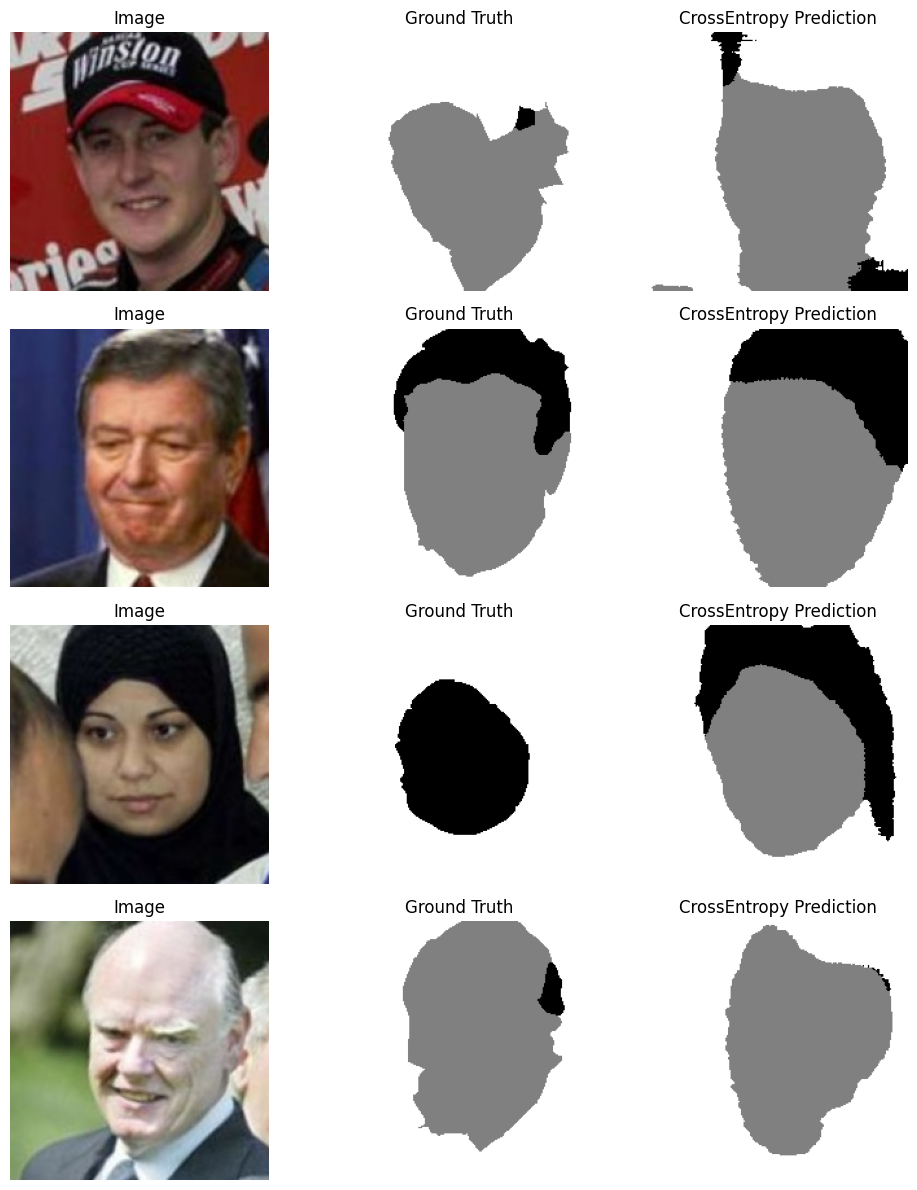

epoch,▁▂▃▃▄▅▆▆▇█
train/freq_weighted_iou,▁▄▅▆▆▇▇███
train/loss,█▅▄▄▃▂▂▁▁▁
train/mean_iou,▁▃▅▅▆▇▇███
train/pixel_accuracy,▁▄▅▆▆▇▇███
val/freq_weighted_iou,▄▁▅▄▆▅███▇
val/loss,▅█▄▄▃▃▂▁▁▂
val/mean_iou,▂▁▅▄▇▅███▇
val/pixel_accuracy,▄▁▅▅▇▅███▇
epoch,10
train/freq_weighted_iou,0.67121



Training with Dice loss


Epoch 1/10 | Train Loss: 0.4589 | Val Loss: 0.3952 | Val mIoU: 0.4860
Epoch 2/10 | Train Loss: 0.3839 | Val Loss: 0.3211 | Val mIoU: 0.5554
Epoch 3/10 | Train Loss: 0.3555 | Val Loss: 0.2935 | Val mIoU: 0.5839
Epoch 4/10 | Train Loss: 0.3459 | Val Loss: 0.3024 | Val mIoU: 0.5753
Epoch 5/10 | Train Loss: 0.3414 | Val Loss: 0.2723 | Val mIoU: 0.6094
Epoch 6/10 | Train Loss: 0.3355 | Val Loss: 0.2695 | Val mIoU: 0.6104
Epoch 7/10 | Train Loss: 0.3258 | Val Loss: 0.2795 | Val mIoU: 0.6003
Epoch 8/10 | Train Loss: 0.3232 | Val Loss: 0.2589 | Val mIoU: 0.6285
Epoch 9/10 | Train Loss: 0.3205 | Val Loss: 0.2580 | Val mIoU: 0.6289
Epoch 10/10 | Train Loss: 0.3165 | Val Loss: 0.2622 | Val mIoU: 0.6261


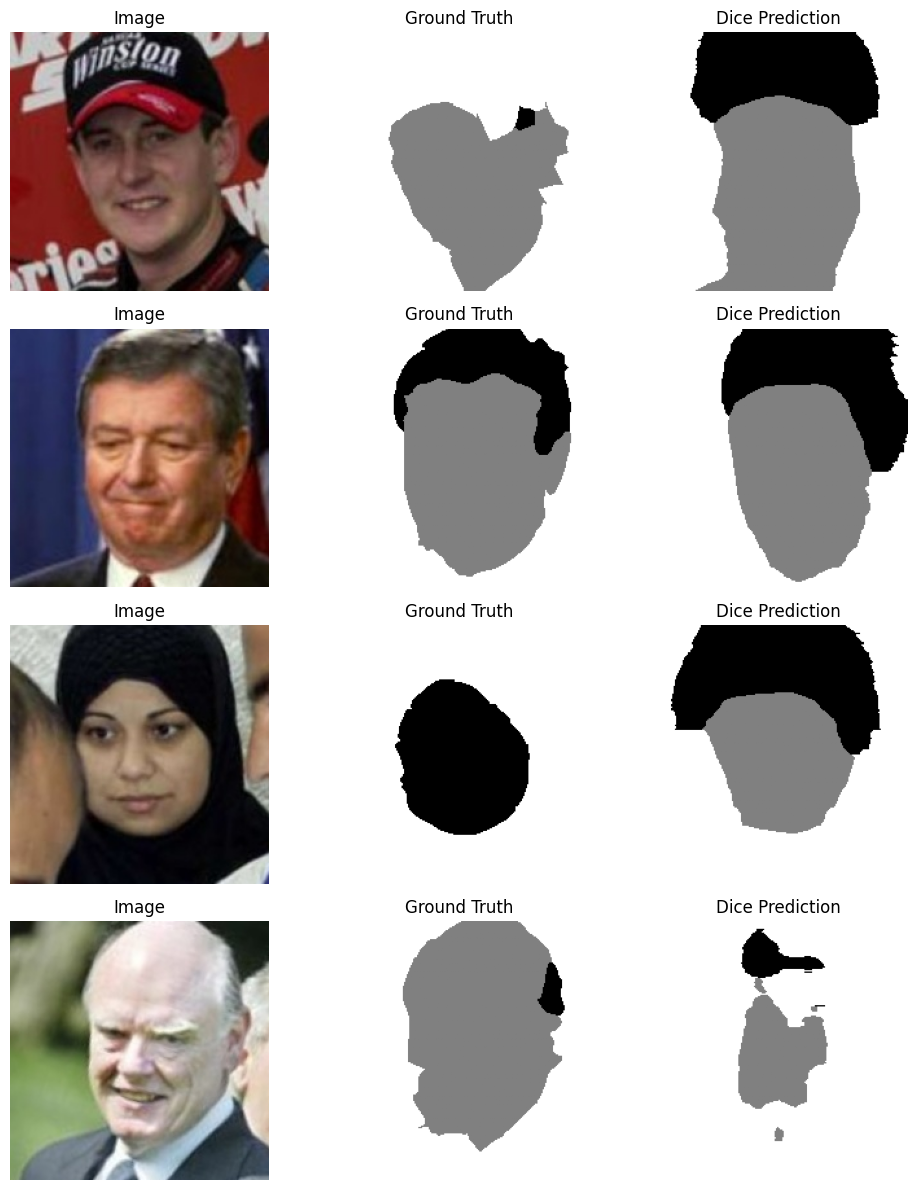

epoch,▁▂▃▃▄▅▆▆▇█
train/freq_weighted_iou,▁▄▆▆▇▇▇███
train/loss,█▄▃▂▂▂▁▁▁▁
train/mean_iou,▁▄▆▆▆▇▇███
train/pixel_accuracy,▁▄▆▆▇▇▇███
val/freq_weighted_iou,▁▄▆▆▇▇▆███
val/loss,█▄▃▃▂▂▂▁▁▁
val/mean_iou,▁▄▆▅▇▇▇███
val/pixel_accuracy,▁▄▆▆▇▇▆██▇
epoch,10
train/freq_weighted_iou,0.63852



Training with Combined loss


Epoch 1/10 | Train Loss: 1.3147 | Val Loss: 1.1523 | Val mIoU: 0.4313
Epoch 2/10 | Train Loss: 1.1230 | Val Loss: 0.8899 | Val mIoU: 0.5741
Epoch 3/10 | Train Loss: 1.0360 | Val Loss: 0.9524 | Val mIoU: 0.5947
Epoch 4/10 | Train Loss: 0.9900 | Val Loss: 0.8378 | Val mIoU: 0.6123
Epoch 5/10 | Train Loss: 0.9518 | Val Loss: 0.8279 | Val mIoU: 0.6273
Epoch 6/10 | Train Loss: 0.9141 | Val Loss: 0.7474 | Val mIoU: 0.6599
Epoch 7/10 | Train Loss: 0.8947 | Val Loss: 0.6848 | Val mIoU: 0.6792
Epoch 8/10 | Train Loss: 0.8668 | Val Loss: 0.7870 | Val mIoU: 0.6428
Epoch 9/10 | Train Loss: 0.8507 | Val Loss: 0.6972 | Val mIoU: 0.6844
Epoch 10/10 | Train Loss: 0.8426 | Val Loss: 0.6769 | Val mIoU: 0.6834


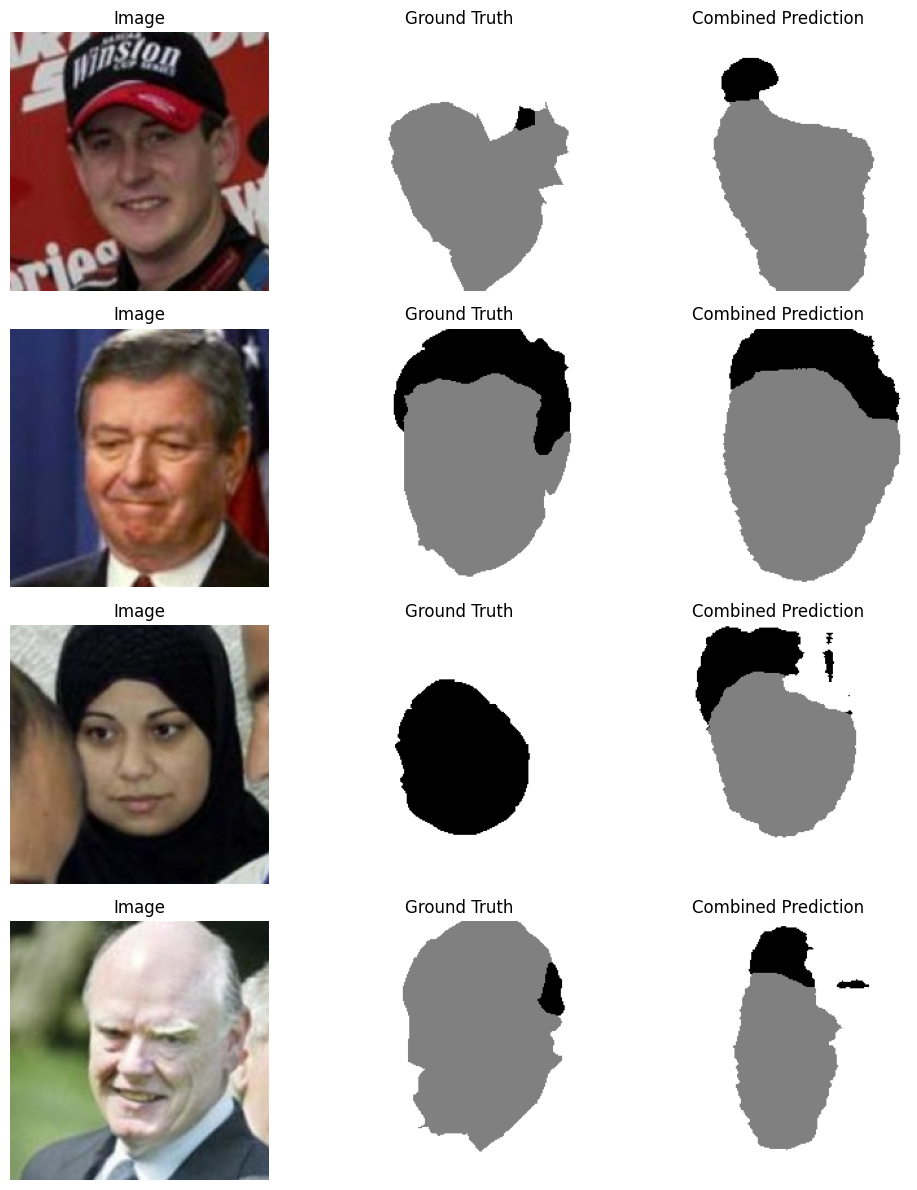

epoch,▁▂▃▃▄▅▆▆▇█
train/freq_weighted_iou,▁▄▆▆▇▇▇███
train/loss,█▅▄▃▃▂▂▁▁▁
train/mean_iou,▁▄▆▆▇▇▇███
train/pixel_accuracy,▁▄▅▆▆▇▇███
val/freq_weighted_iou,▁▅▅▅▅▇▇▆██
val/loss,█▄▅▃▃▂▁▃▁▁
val/mean_iou,▁▅▆▆▆▇█▇██
val/pixel_accuracy,▁▅▄▅▅▆▇▅▇█
epoch,10
train/freq_weighted_iou,0.67801



Training with Focal loss


Epoch 1/10 | Train Loss: 0.3360 | Val Loss: 0.4982 | Val mIoU: 0.3227
Epoch 2/10 | Train Loss: 0.2719 | Val Loss: 0.3166 | Val mIoU: 0.3731
Epoch 3/10 | Train Loss: 0.2501 | Val Loss: 0.2560 | Val mIoU: 0.4917
Epoch 4/10 | Train Loss: 0.2388 | Val Loss: 0.2311 | Val mIoU: 0.5541
Epoch 5/10 | Train Loss: 0.2290 | Val Loss: 0.2001 | Val mIoU: 0.6002
Epoch 6/10 | Train Loss: 0.2176 | Val Loss: 0.1935 | Val mIoU: 0.6067
Epoch 7/10 | Train Loss: 0.2171 | Val Loss: 0.1928 | Val mIoU: 0.5906
Epoch 8/10 | Train Loss: 0.2106 | Val Loss: 0.1822 | Val mIoU: 0.5952
Epoch 9/10 | Train Loss: 0.2052 | Val Loss: 0.1663 | Val mIoU: 0.6489
Epoch 10/10 | Train Loss: 0.1980 | Val Loss: 0.1628 | Val mIoU: 0.6457


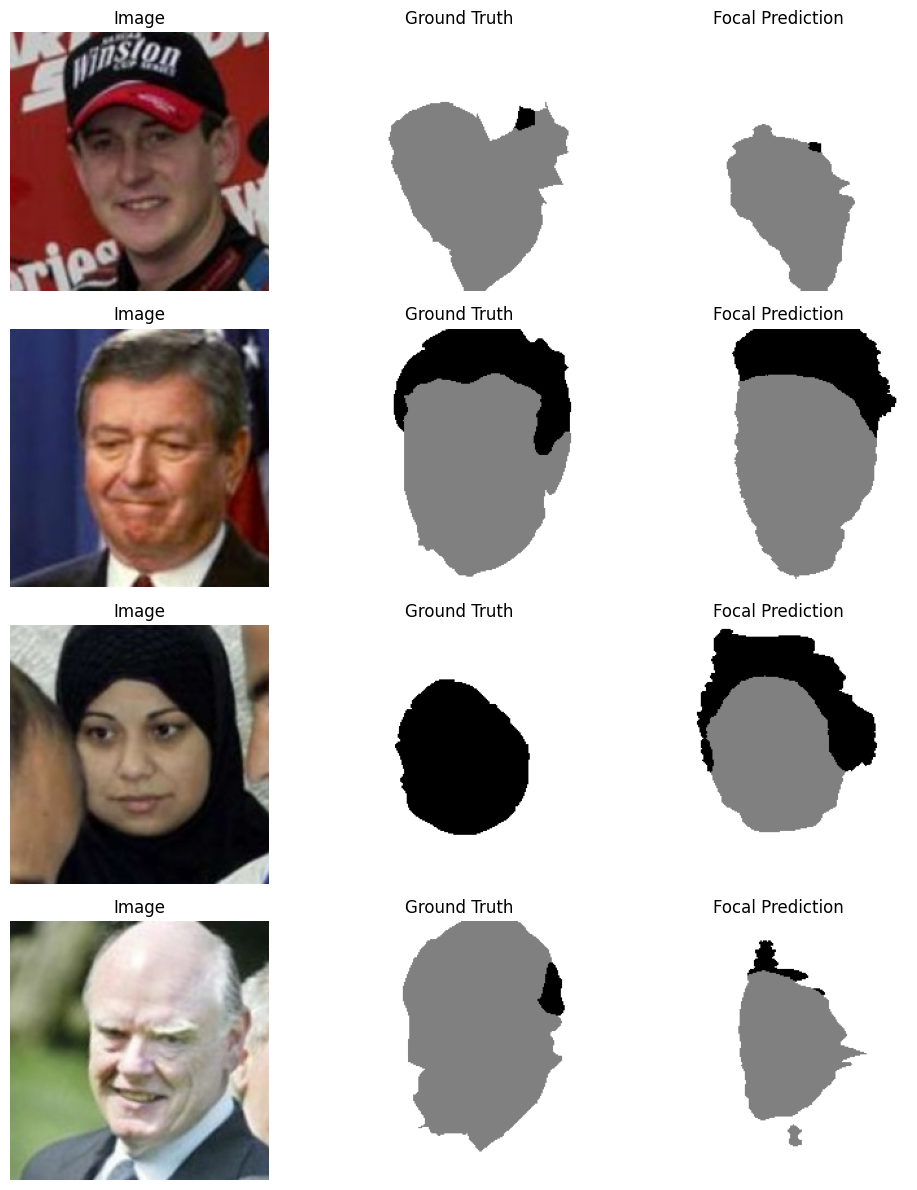

epoch,▁▂▃▃▄▅▆▆▇█
train/freq_weighted_iou,▁▅▆▆▇▇▇▇██
train/loss,█▅▄▃▃▂▂▂▁▁
train/mean_iou,▁▅▆▆▇▇▇▇██
train/pixel_accuracy,▁▅▆▆▇▇▇▇██
val/freq_weighted_iou,▁▂▅▆▇▇▇▇██
val/loss,█▄▃▂▂▂▂▁▁▁
val/mean_iou,▁▂▅▆▇▇▇▇██
val/pixel_accuracy,▁▃▆▆▇▇▇▇██
epoch,10
train/freq_weighted_iou,0.65168


In [27]:
criterions = {
    "CrossEntropy": ce_criterion,
    "Dice": dice_criterion,
    "Combined": combined_criterion,
    "Focal": focal_criterion,
}

for name, criterion in criterions.items():
    print(f"\n{'='*50}")
    print(f"Training with {name} loss")
    print(f"{'='*50}")

    run = wandb.init(
        project="computer-vision",
        group="lab4",
        name=name,
        config={"loss": name, "lr": 1e-3, "epochs": 10, "batch_size": 4},
        reinit=True,
    )

    model = UNet(num_classes=NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    training(
        model, train_loader, val_loader,
        optimizer, criterion, device, epochs=10,
    )

    # final visualization in notebook
    model.eval()
    images, masks = next(iter(val_loader))
    images = images.to(device)
    with torch.no_grad():
        predictions = model(images)
    pred_masks = torch.argmax(predictions, dim=1).cpu()

    fig, axes = plt.subplots(4, 3, figsize=(10, 12))
    for i in range(min(4, images.shape[0])):
        axes[i, 0].imshow(images[i].cpu().permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i].numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_masks[i].numpy(), cmap="gray")
        axes[i, 2].set_title(f"{name} Prediction")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

    wandb.finish()

## Post-processing

In [28]:
def confidence_threshold(logits, threshold=0.6):
    """Set low-confidence pixels to background (class 0)."""
    probs = F.softmax(logits, dim=1)
    max_probs, pred_mask = probs.max(dim=1)
    pred_mask[max_probs < threshold] = 0
    return pred_mask

def spatial_smoothing(logits, kernel_size=5):
    """Average probabilities in a local neighborhood before taking argmax."""
    probs = F.softmax(logits, dim=1)
    padding = kernel_size // 2
    kernel = torch.ones(1, 1, kernel_size, kernel_size, device=logits.device) / (kernel_size ** 2)
    smoothed = torch.cat([
        F.conv2d(probs[:, c:c+1], kernel, padding=padding)
        for c in range(probs.shape[1])
    ], dim=1)
    return smoothed.argmax(dim=1)

def remove_small_regions(mask_np, min_area=50):
    """Remove connected components smaller than min_area pixels."""
    cleaned = mask_np.copy()
    for cls in range(1, mask_np.max() + 1):
        binary = (mask_np == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        for label_id in range(1, num_labels):
            if stats[label_id, cv2.CC_STAT_AREA] < min_area:
                cleaned[labels == label_id] = 0
    return cleaned

In [29]:
model.eval()

all_logits = []
all_masks = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_masks.append(masks)

all_logits = torch.cat(all_logits)
all_masks = torch.cat(all_masks)

# --- Baseline: plain argmax ---
baseline_preds = all_logits.argmax(dim=1)
baseline_acc = pixel_accuracy(all_logits, all_masks).item()
baseline_miou, _ = mean_iou(all_logits, all_masks, NUM_CLASSES)
baseline_fwiou = frequency_weighted_iou(all_logits, all_masks, NUM_CLASSES).item()

# --- Confidence thresholding ---
conf_preds = confidence_threshold(all_logits, threshold=0.6)
conf_acc = (conf_preds == all_masks).float().mean().item()
conf_miou, _ = mean_iou(F.one_hot(conf_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(), all_masks, NUM_CLASSES,)
conf_fwiou = frequency_weighted_iou(F.one_hot(conf_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(), all_masks, NUM_CLASSES,).item()

# --- Spatial smoothing ---
smooth_preds = spatial_smoothing(all_logits, kernel_size=5)
smooth_acc = (smooth_preds == all_masks).float().mean().item()
smooth_miou, _ = mean_iou(F.one_hot(smooth_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(), all_masks, NUM_CLASSES,)
smooth_fwiou = frequency_weighted_iou(F.one_hot(smooth_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(), all_masks, NUM_CLASSES,).item()

# --- Small region removal ---
region_preds = baseline_preds.clone()
for i in range(region_preds.shape[0]):
    region_preds[i] = torch.from_numpy(remove_small_regions(region_preds[i].numpy(), min_area=50))
region_acc = (region_preds == all_masks).float().mean().item()
region_miou, _ = mean_iou(F.one_hot(region_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(),all_masks, NUM_CLASSES,)
region_fwiou = frequency_weighted_iou(F.one_hot(region_preds, NUM_CLASSES).permute(0, 3, 1, 2).float(), all_masks, NUM_CLASSES,).item()

print(f"{'Method':<25} {'Pixel Acc':>10} {'Mean IoU':>10} {'FW IoU':>10}")
print("-" * 57)
print(f"{'Baseline (argmax)':<25} {baseline_acc:>10.4f} {baseline_miou.item():>10.4f} {baseline_fwiou:>10.4f}")
print(f"{'Confidence (t=0.6)':<25} {conf_acc:>10.4f} {conf_miou.item():>10.4f} {conf_fwiou:>10.4f}")
print(f"{'Spatial smoothing (k=5)':<25} {smooth_acc:>10.4f} {smooth_miou.item():>10.4f} {smooth_fwiou:>10.4f}")
print(f"{'Region filter (min=50)':<25} {region_acc:>10.4f} {region_miou.item():>10.4f} {region_fwiou:>10.4f}")

Method                     Pixel Acc   Mean IoU     FW IoU
---------------------------------------------------------
Baseline (argmax)             0.8310     0.6467     0.7140
Confidence (t=0.6)            0.6561     0.4719     0.5508
Spatial smoothing (k=5)       0.8314     0.6471     0.7145
Region filter (min=50)        0.8310     0.6467     0.7140


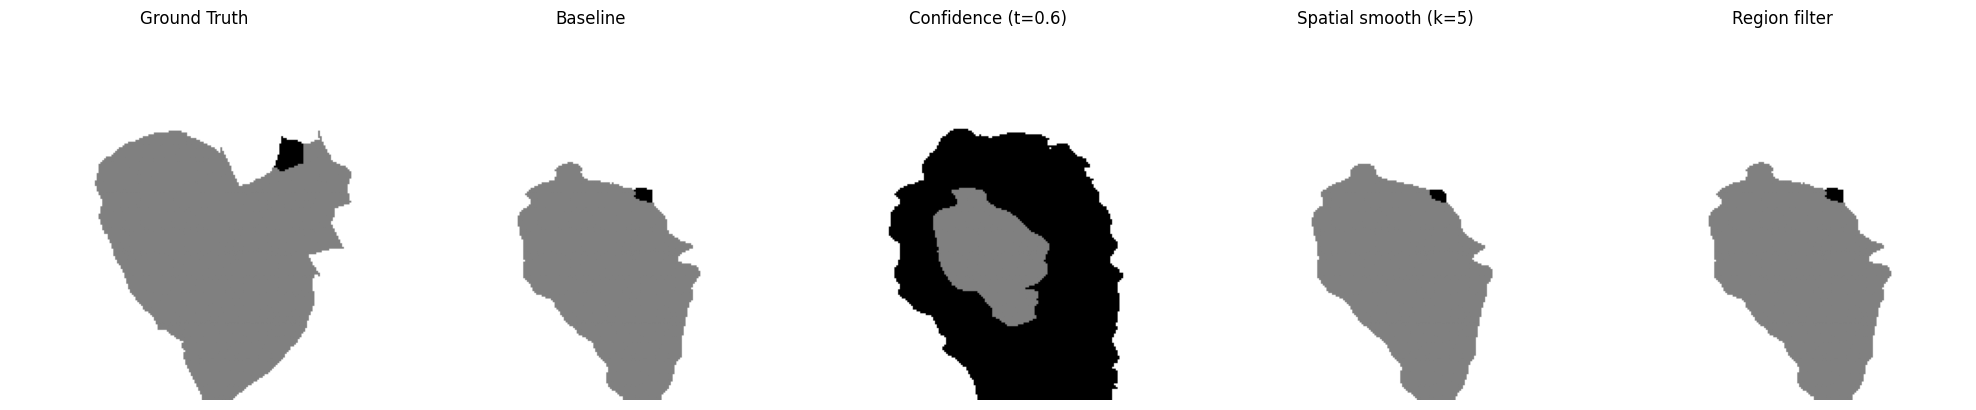

In [30]:
sample_idx = 0
sample_logits = all_logits[sample_idx:sample_idx+1]
sample_mask = all_masks[sample_idx]

methods = {
    "Baseline": baseline_preds[sample_idx],
    "Confidence (t=0.6)": conf_preds[sample_idx],
    "Spatial smooth (k=5)": smooth_preds[sample_idx],
    "Region filter": region_preds[sample_idx],
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(sample_mask.numpy(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

for i, (name, pred) in enumerate(methods.items()):
    axes[i + 1].imshow(pred.numpy(), cmap="gray")
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

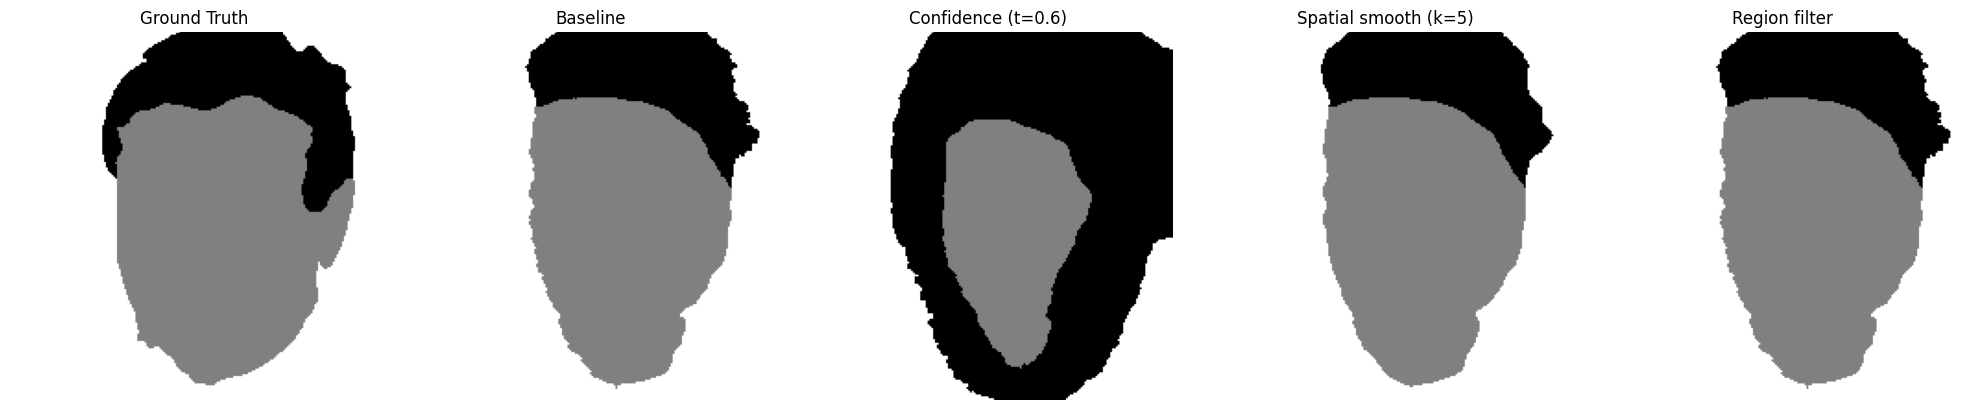

In [31]:
sample_idx = 1
sample_logits = all_logits[sample_idx:sample_idx+1]
sample_mask = all_masks[sample_idx]

methods = {
    "Baseline": baseline_preds[sample_idx],
    "Confidence (t=0.6)": conf_preds[sample_idx],
    "Spatial smooth (k=5)": smooth_preds[sample_idx],
    "Region filter": region_preds[sample_idx],
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(sample_mask.numpy(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

for i, (name, pred) in enumerate(methods.items()):
    axes[i + 1].imshow(pred.numpy(), cmap="gray")
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

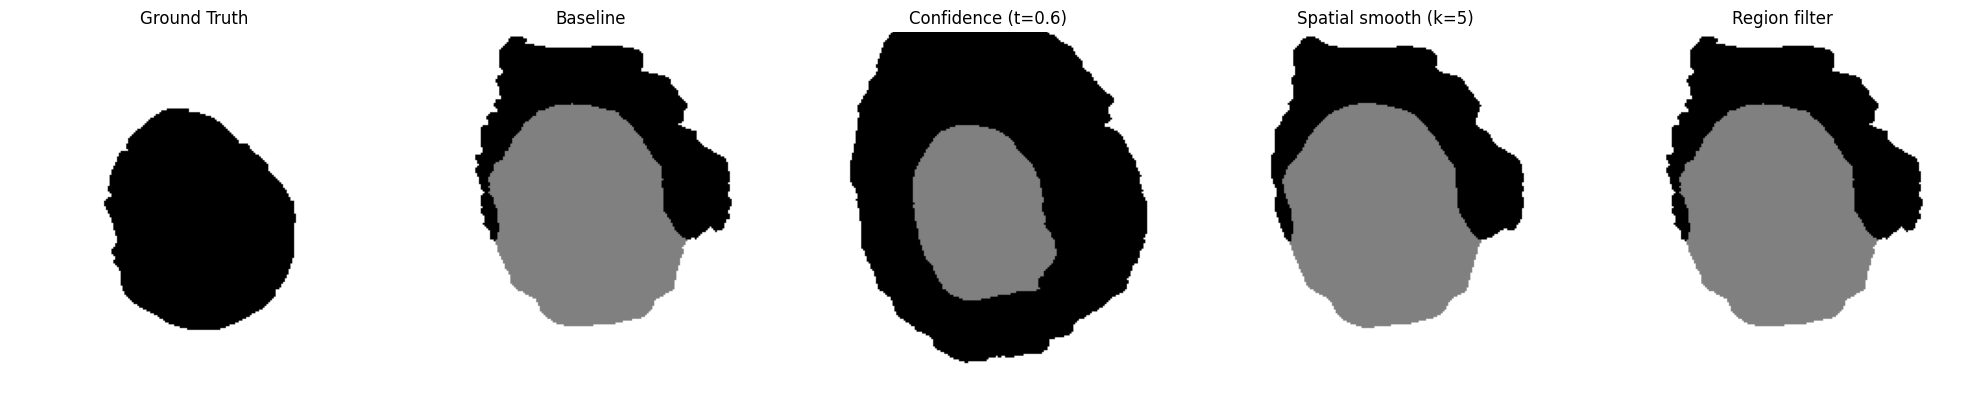

In [32]:
sample_idx = 2
sample_logits = all_logits[sample_idx:sample_idx+1]
sample_mask = all_masks[sample_idx]

methods = {
    "Baseline": baseline_preds[sample_idx],
    "Confidence (t=0.6)": conf_preds[sample_idx],
    "Spatial smooth (k=5)": smooth_preds[sample_idx],
    "Region filter": region_preds[sample_idx],
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(sample_mask.numpy(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

for i, (name, pred) in enumerate(methods.items()):
    axes[i + 1].imshow(pred.numpy(), cmap="gray")
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

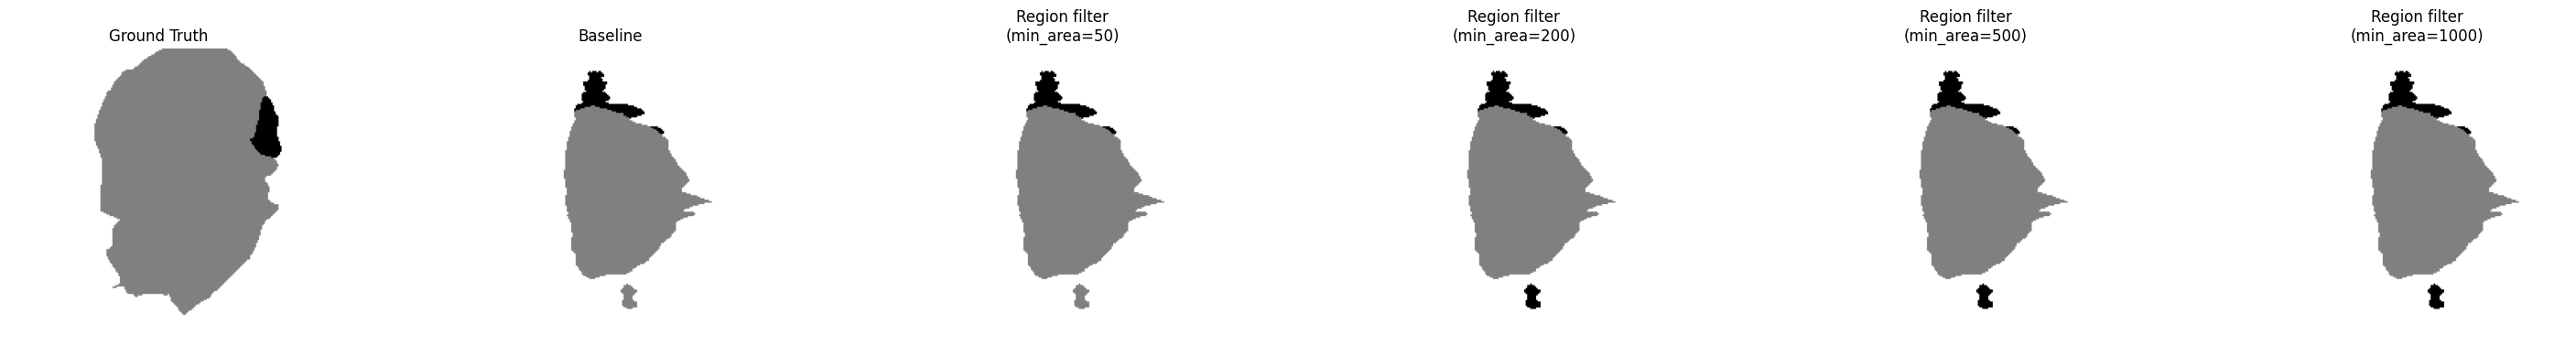

In [34]:
sample_idx = 3
sample_mask = all_masks[sample_idx]
baseline = baseline_preds[sample_idx].numpy()

min_areas = [50, 200, 500, 1000]

fig, axes = plt.subplots(1, 2 + len(min_areas), figsize=(5 * (2 + len(min_areas)), 4))

axes[0].imshow(sample_mask.numpy(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(baseline, cmap="gray")
axes[1].set_title("Baseline")
axes[1].axis("off")

for i, ma in enumerate(min_areas):
    cleaned = remove_small_regions(baseline, min_area=ma)
    axes[i + 2].imshow(cleaned, cmap="gray")
    axes[i + 2].set_title(f"Region filter\n(min_area={ma})")
    axes[i + 2].axis("off")

plt.tight_layout()
plt.show()